# Fase 3 — IBGE, Censo Escolar e validação em 2025

Evolução da referência inicial: **12 novos atributos**, 21 preditores no total, e teste em outra edição. Este notebook lê artefatos da execução `python main.py temporal --execution-date 2026-09-08`.

**Resultado central:** o enriquecimento melhorou a validação em 2024, mas não melhorou o F1 no teste de 2025. Essa conclusão é preservada, sem selecionar novamente pelo teste.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Markdown, Image

RAIZ = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p/'reports/resultados_temporais.json').is_file()), None)
if RAIZ is None:
    raise FileNotFoundError('Execute a etapa temporal na raiz da Fase 3.')
def ler(nome):
    return json.loads((RAIZ/'reports'/nome).read_text(encoding='utf-8'))
def figura(nome):
    display(Image(filename=str(RAIZ/'images'/nome), width=1000))
r = ler('resultados_temporais.json')
m = ler('proveniencia_enriquecimento.json')
s = ler('selecao_temporal_antes_teste.json')
assert r['run_id'] == s['run_id']
assert r['selecao']['modelo_sha256'] == s['modelo_sha256']
assert r['novas_features'] == m['novas_features']
display(Markdown(f"**Execução:** `{r['run_id']}` · **Gold:** `{r['execucao_gold']}`"))

**Execução:** `20260908T020719980300Z_temporal` · **Gold:** `2026-09-08`

## 1. O que foi acrescentado à Gold

IBGE: população residente por município. Censo: escolas ativas com matrículas nos anos iniciais, agregadas por município e rede. Não há ligação de escolas pela máscara de identificação da avaliação.

Docentes são vínculos por escola; taxas de infraestrutura usam respostas válidas. Denominadores zero e valores ausentes permanecem nulos.

In [2]:
display(pd.DataFrame({'novos_atributos': r['novas_features']}))
linhas = []
for ano, c in m['cobertura'].items():
    linhas.append({'ano': ano, 'Gold': c['linhas_gold'], 'elegíveis': c['elegiveis'], 'UFs': len(c['ufs']), 'IBGE (%)': c['cobertura_populacao_pct'], 'Censo (%)': c['cobertura_censo_pct'], 'referência IBGE': c['ano_ibge'], 'referência Censo': c['ano_censo']})
display(pd.DataFrame(linhas).round(4))
display(pd.Series(m['auditoria_ingestao_2025'], name='registros').to_frame())

,novos_atributos
0,populacao_municipio_ibge
1,escolas_anos_iniciais_censo
2,matriculas_anos_iniciais_censo
3,vinculos_docentes_anos_iniciais_censo
4,turmas_anos_iniciais_censo
5,pct_escolas_rurais_censo
6,pct_escolas_internet_censo
7,pct_escolas_agua_potavel_censo
8,pct_escolas_biblioteca_censo
9,pct_escolas_lab_informatica_censo


,ano,Gold,elegíveis,UFs,IBGE (%),Censo (%),referência IBGE,referência Censo
0,2023,1747439,1502809,23,100.0000,99.9950,2021,2022
1,2024,2120560,1851852,26,100.0000,100.0000,2022,2023
2,2025,2222164,1966095,27,99.9944,99.9938,2024,2024


,registros
linhas_bronze,2222792
quarentena_sem_chave,628


A edição 2025 acrescenta Roraima. Dos 2.222.792 registros originais, 628 não têm município, escola e rede: ficam em quarentena, com rastreabilidade. Ausentes na avaliação e presentes sem proficiência válida também não são usados como rótulos de não alfabetização.

O ano de referência anterior não comprova a disponibilidade histórica da versão baixada. O estudo permanece retrospectivo.

## 2. Exemplo dos novos valores de contexto

Quando a Gold está disponível localmente, a célula abaixo mostra um contexto de município/rede de 2024, sem expor registro individual.

In [3]:
import pyarrow.parquet as pq
arquivo = RAIZ.parent/'fiap-tech-challenge-fase2/data/gold/base_modelagem_aluno_enriquecida'/f"execution_date={r['execucao_gold']}"/'ano=2024/base_modelagem_aluno_enriquecida.parquet'
if arquivo.exists():
    colunas = ['id_municipio_nome','sigla_uf','rede','ano_referencia_ibge','ano_referencia_censo'] + r['novas_features']
    lote = next(pq.ParquetFile(arquivo).iter_batches(batch_size=1, columns=colunas)).to_pandas()
    display(lote.T.rename(columns={0: 'valor do contexto'}))
else:
    display(Markdown('Gold não materializada neste clone. Siga os comandos de reprodução ao final.'))

,valor do contexto
id_municipio_nome,Alta Floresta D'Oeste
sigla_uf,RO
rede,Municipal
ano_referencia_ibge,2022
ano_referencia_censo,2023
populacao_municipio_ibge,21494
escolas_anos_iniciais_censo,12
matriculas_anos_iniciais_censo,1368.0
vinculos_docentes_anos_iniciais_censo,62.0
turmas_anos_iniciais_censo,58.0


## 3. EDA e separação temporal

As hipóteses de porte, recursos e organização da rede são examinadas no treino de 2024. Imputação e transformações fazem parte do pipeline, dentro das dobras.

O antigo teste de 2024 vira conjunto de calibração nesta rodada. O teste novo é 2025. As identidades escolares não são comparáveis entre edições.

In [4]:
eda = ler('eda_enriquecida.json')
display(pd.DataFrame(eda['novas_numericas']).T.round(3))
display(pd.Series(eda['ausencias_pct'], name='ausência no treino (%)').to_frame())
display(pd.DataFrame(r['divisao_desenvolvimento']).T)

,count,mean,std,min,25%,50%,75%,max
populacao_municipio_ibge,1112203.0,1082514.672,2696125.701,833.000,29924.000,115791.000,480393.000,1.145200e+07
escolas_anos_iniciais_censo,1112203.0,96.546,170.578,1.000,12.000,30.000,79.000,7.570000e+02
matriculas_anos_iniciais_censo,1112203.0,34760.608,74080.590,19.000,1717.000,6060.000,22773.000,3.191320e+05
vinculos_docentes_anos_iniciais_censo,1112203.0,1708.607,3610.990,2.000,98.000,317.000,1121.000,1.536000e+04
turmas_anos_iniciais_censo,1112203.0,1295.562,2630.571,1.000,79.000,253.000,918.000,1.107000e+04
pct_escolas_rurais_censo,1112203.0,28.362,30.632,0.000,0.000,16.667,50.000,1.000000e+02
pct_escolas_internet_censo,1112203.0,94.710,13.667,0.000,97.826,100.000,100.000,1.000000e+02
pct_escolas_agua_potavel_censo,1112203.0,97.156,10.665,0.000,100.000,100.000,100.000,1.000000e+02
pct_escolas_biblioteca_censo,1112203.0,39.111,33.970,0.000,7.143,31.250,66.169,1.000000e+02
pct_escolas_lab_informatica_censo,1112203.0,43.939,34.240,0.000,11.111,40.000,75.000,1.000000e+02


,ausência no treino (%)
rede,0.000000
sigla_uf,0.000000
regiao_brasil,0.000000
taxa_alfabetizacao_municipio_anterior,23.172388
taxa_presenca_municipio_anterior,23.168432
alunos_avaliados_municipio_anterior,23.172388
total_pagamentos_bolsa_familia_anterior,0.000000
valor_total_bolsa_familia_anterior,0.000000
valor_medio_pagamento_bolsa_familia_anterior,0.000000
populacao_municipio_ibge,0.000000


,linhas,escolas,indices_sha256
treino,1112203,25396,fdaaf18d39d6b2df375d8728741e2dd9bab503fa7fa453...
validacao,370443,8466,3589a544541c9280c0072f5de8a02c201ff7a11a197593...
calibracao,369206,8466,6ed4739341dd6d02ff2120350cbc8dc98c036dce4f63ef...


## 4. Busca e escolha em 2024

Comparação: baseline, logística com nove atributos, logística com 21 atributos e boosting com 21. Busca em escolas inteiras do treino, três dobras agrupadas; vencedor pelo F1 macro na validação. O limiar é 0,5.

In [5]:
display(pd.DataFrame(r['validacao']).T[['f1_macro','recall_risco','roc_auc','brier']].round(4))
display(pd.DataFrame([{'modelo': nome, 'parâmetros': b['melhores_parametros'], 'linhas CV': b['linhas'], 'dobras': b['dobras']} for nome,b in r['busca'].items()]))
display(pd.Series(s, name='congelamento antes de abrir 2025').to_frame())
assert s['teste_usado_na_selecao'] is False

,f1_macro,recall_risco,roc_auc,brier
baseline,0.373321,0.0,0.5,0.240845
referencia_logistica,0.594511,0.646172,0.652505,0.231919
enriquecida_logistica,0.599385,0.63209,0.653553,0.23173
enriquecida_boosting,0.588382,0.364331,0.663295,0.221577


,modelo,parâmetros,linhas CV,dobras
0,referencia_logistica,"{'modelo__C': 1.0, 'modelo__class_weight': 'ba...",149967,3
1,enriquecida_logistica,"{'modelo__C': 1.0, 'modelo__class_weight': 'ba...",149967,3
2,enriquecida_boosting,"{'modelo__max_leaf_nodes': 31, 'modelo__min_sa...",149967,3


,congelamento antes de abrir 2025
modelo,enriquecida_logistica
criterio,maior F1 macro de validação antes de calibrar;...
ano_treino,2024
ano_teste,2025
limiar,0.5
calibracao,"sigmoid fixa, em 20% de escolas de desenvolvim..."
teste_usado_na_selecao,False
run_id,20260908T020719980300Z_temporal
modelo_sha256,0ca5a666c14111e0d1d62a14f5b2439dd384cd9467ad2a...
congelado_em_utc,2026-09-08T02:09:41.740751+00:00


## 5. Teste em 2025

Depois da escolha, os candidatos são reajustados em treino+validação. O vencedor recebe calibração sigmoide nos 20% de escolas de 2024 reservados para esse fim, usando FrozenEstimator. Seleção, modelo e hash são salvos antes de carregar 2025.

,f1_macro,recall_risco,precisao_risco,roc_auc,brier
baseline,0.398523,0.0,0.0,0.5,0.2278
referencia_logistica,0.583853,0.494965,0.440236,0.631075,0.233324
enriquecida_logistica,0.583326,0.494311,0.439589,0.630101,0.233985
enriquecida_boosting,0.559256,0.278987,0.481766,0.634485,0.215945
selecionado_calibrado,0.566597,0.319495,0.467127,0.630101,0.218227


**Diferença de F1 entre logísticas no teste: -0.0005.**

{'metodo': 'bootstrap de escolas, percentis 2.5/97.5; modelo fixo',
 'repeticoes': 300,
 'escolas': 43538,
 'f1_macro_ic95': [0.5643341559080087, 0.5687960943503411],
 'recall_risco_ic95': [0.3133886116976447, 0.3258821082497784]}

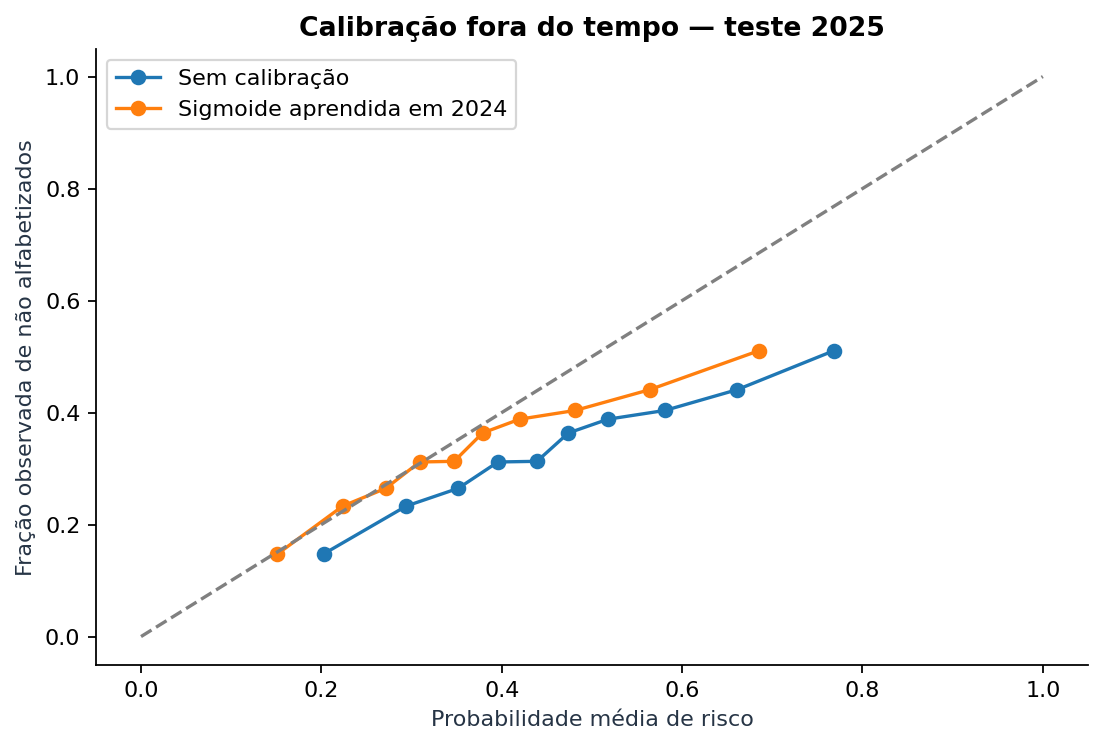

In [6]:
metricas = ['f1_macro','recall_risco','precisao_risco','roc_auc','brier']
display(pd.DataFrame(r['teste']).T[metricas].round(4))
delta = r['teste']['enriquecida_logistica']['f1_macro'] - r['teste']['referencia_logistica']['f1_macro']
display(Markdown(f'**Diferença de F1 entre logísticas no teste: {delta:+.4f}.**'))
display(r['incerteza_escolas'])
figura('temporal_calibracao.png')

O ganho em validação não se confirmou no teste temporal. A calibração melhorou o Brier, mas reduziu F1 e recall no limiar 0,5. A curva também mostra que os scores altos continuam superestimando risco em 2025.

O modelo não foi trocado após essa observação. Ajustar o limiar agora usando 2025 contaminaria a avaliação final.

## 6. Interpretação e recortes

Permutação: 5.000 avaliações de teste, cinco repetições. Mede sensibilidade do F1, sem implicar causalidade. Não houve nova seleção de atributos baseada nesse diagnóstico.

,variavel,queda_f1_macro,desvio
0,taxa_alfabetizacao_municipio_anterior,0.05192,0.00407
1,taxa_presenca_municipio_anterior,0.00851,0.00235
2,sigla_uf,0.00473,0.00455
3,valor_total_bolsa_familia_anterior,0.00281,0.00255
4,total_pagamentos_bolsa_familia_anterior,0.00249,0.00261
5,pct_escolas_internet_censo,0.00237,0.00024
6,valor_medio_pagamento_bolsa_familia_anterior,0.00201,0.00178
7,regiao_brasil,0.00150,0.00377
8,escolas_anos_iniciais_censo,0.00050,0.00076
9,pct_escolas_lab_informatica_censo,0.00026,0.00102


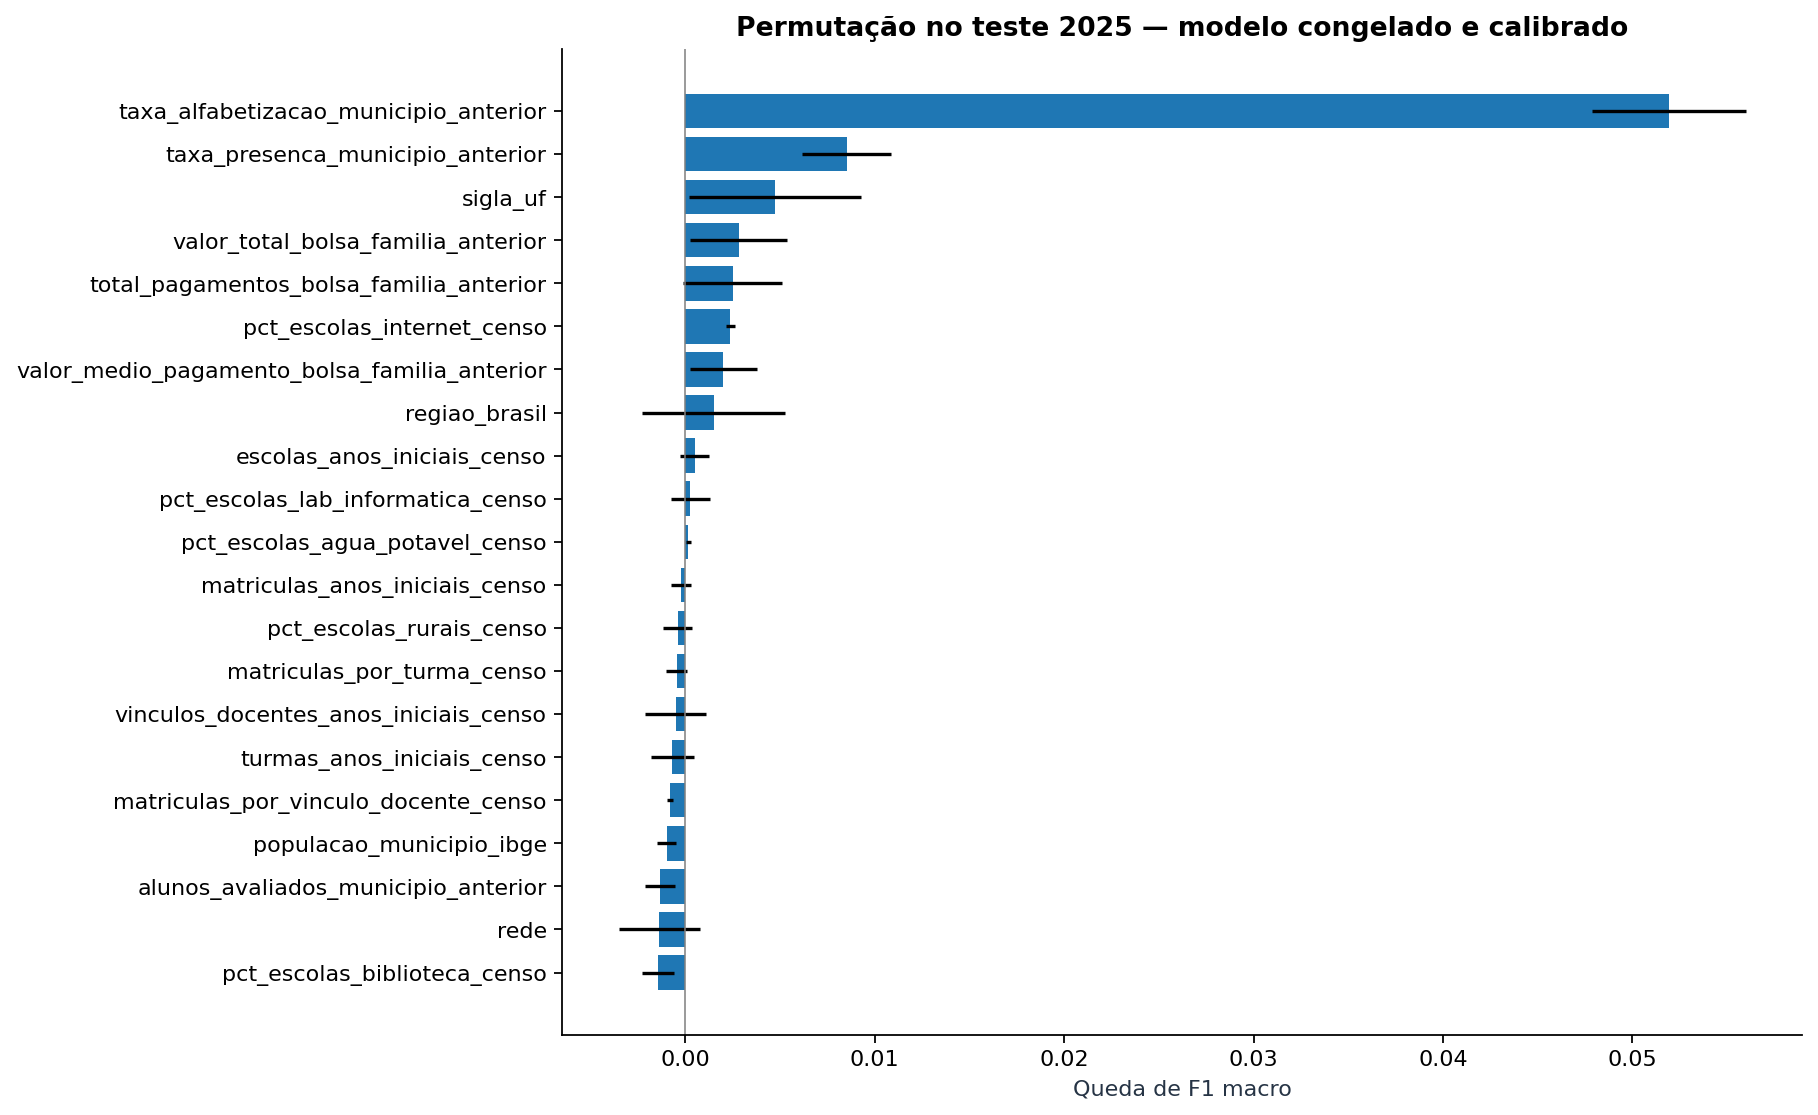

,grupo,n,f1_macro,recall_risco,roc_auc
0,Centro-Oeste,181586,0.4621,0.0404,0.6240
1,Nordeste,502869,0.6040,0.5250,0.6682
2,Norte,211073,0.5438,0.6668,0.5982
3,Sudeste,768370,0.4555,0.0695,0.6164
4,Sul,302197,0.6118,0.4898,0.6708


,grupo,n,f1_macro,recall_risco,roc_auc
0,False,1956785,0.5662,0.3160,0.6303
1,True,9310,0.3324,0.9023,0.4995


In [7]:
display(pd.DataFrame(r['permutacao']).round(5))
figura('temporal_permutacao.png')
display(pd.DataFrame(r['recortes_teste']['regiao_brasil'])[['grupo','n','f1_macro','recall_risco','roc_auc']].round(4))
display(pd.DataFrame(r['recortes_teste']['uf_nova'])[['grupo','n','f1_macro','recall_risco','roc_auc']].round(4))

O grupo `uf_nova=True` corresponde a Roraima: 9.310 avaliações, AUC próxima de 0,5 e F1 0,3324. Esse resultado mostra dificuldade para generalizar a um contexto que não estava no desenvolvimento.

O histórico municipal continua mais relevante que os atributos adicionais. Internet aparece entre as contribuições positivas do Censo, enquanto outras importâncias são pequenas ou negativas nesta amostra.

## 7. Diagnóstico territorial e metas futuras

Os grupos abaixo têm pelo menos 100 avaliações e três escolas. São um diagnóstico agregado de 2025, sem equivalência a taxa oficial nem previsão de metas futuras.

In [8]:
display(pd.DataFrame(r['ranking_diagnostico_2025']).head(10))
assert r['metas_futuras_habilitadas'] is False
display(Markdown('\n'.join('- ' + limite for limite in r['limites'])))

,sigla_uf,id_municipio,id_municipio_nome,rede,avaliacoes,escolas,score_medio,fracao_nao_alfabetizada
0,RS,4314902,Porto Alegre,Municipal,2677,51,0.843289,0.727307
1,RS,4306767,Eldorado do Sul,Municipal,360,10,0.814112,0.711111
2,RS,4304663,Capão do Leão,Municipal,265,8,0.803713,0.656604
3,RS,4305454,Cidreira,Municipal,145,4,0.801631,0.689655
4,RS,4309308,Guaíba,Municipal,832,20,0.791427,0.588942
5,RS,4316402,Rosário do Sul,Municipal,108,4,0.788797,0.666667
6,RS,4313953,Pantano Grande,Municipal,118,4,0.787533,0.449153
7,RS,4314407,Pelotas,Municipal,1367,48,0.784881,0.698610
8,RS,4300604,Alvorada,Municipal,1568,28,0.784717,0.589286
9,RS,4304630,Capão da Canoa,Municipal,507,12,0.778999,0.593688


- Teste de outra edição; identidades escolares não são longitudinais.
- Datas e versões históricas de publicação não estão integralmente comprovadas.
- Calibração aprendida em 2024 pode se degradar com mudanças em 2025.
- População de 2022 é censo; 2024 é estimativa; não inferir crescimento diretamente.
- Resultados não ponderados por desenho amostral; não estimam indicadores oficiais.
- Não prever metas futuras até validar disponibilidade temporal, agregação e incerteza.

## 8. Reproduzir e entregar

Na Fase 2, após materializar a base inicial:

```powershell
python -m src.bronze.download_enriquecimento --execution-date 2026-09-08
python -m src.gold.enriquecer_modelagem --execution-date 2026-09-08 --origem-execution-date 2026-09-07
```

Na Fase 3:

```powershell
python -m pytest tests/ -q
python main.py temporal --execution-date 2026-09-08 --ano-treino 2024 --ano-teste 2025
```

Veja o [relatório](../reports/resultados_temporais.md), o [protocolo](../reports/protocolo_temporal.md) e o [contrato da Gold](../../fiap-tech-challenge-fase2/docs/enriquecimento_ibge_censo.md).

Para a entrega ainda faltam gravação do vídeo executivo e PR/revisão colaborativa. Um novo teste de metas exige disponibilidade temporal comprovada e validação da agregação municipal.